In [ ]:
from google.colab import files
uploaded = files.upload()  # Upload both train.csv and test.csv

Saving train_u6lujuX_CVtuZ9i.csv to train_u6lujuX_CVtuZ9i.csv
Saving test_Y3wMUE5_7gLdaTN.csv to test_Y3wMUE5_7gLdaTN.csv


In [ ]:
import pandas as pd

train = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')
test = pd.read_csv('test_Y3wMUE5_7gLdaTN.csv')

# Display dataset
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
# Drop rows with missing target
train.dropna(subset=['Loan_Status'], inplace=True)

# Fill missing values
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History', 'Loan_Amount_Term']:
    train[col].fillna(train[col].mode()[0], inplace=True)
    test[col].fillna(test[col].mode()[0], inplace=True)

train['LoanAmount'].fillna(train['LoanAmount'].median(), inplace=True)
test['LoanAmount'].fillna(test['LoanAmount'].median(), inplace=True)

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Dependents']
le = LabelEncoder()

for col in categorical_cols + ['Loan_Status']:
    train[col] = le.fit_transform(train[col].astype(str))

for col in categorical_cols:
    test[col] = le.fit_transform(test[col].astype(str))


/tmp/ipython-input-2225830982.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(train[col].mode()[0], inplace=True)
/tmp/ipython-input-2225830982.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Features and target
X = train.drop(columns=['Loan_ID', 'Loan_Status'])
y = train['Loan_Status']

# Split for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=0)
model.fit(X_train, y_train)

# Validation
y_pred = model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))


Validation Accuracy: 0.7642276422764228
              precision    recall  f1-score   support

           0       0.79      0.44      0.57        43
           1       0.76      0.94      0.84        80

    accuracy                           0.76       123
   macro avg       0.77      0.69      0.70       123
weighted avg       0.77      0.76      0.74       123



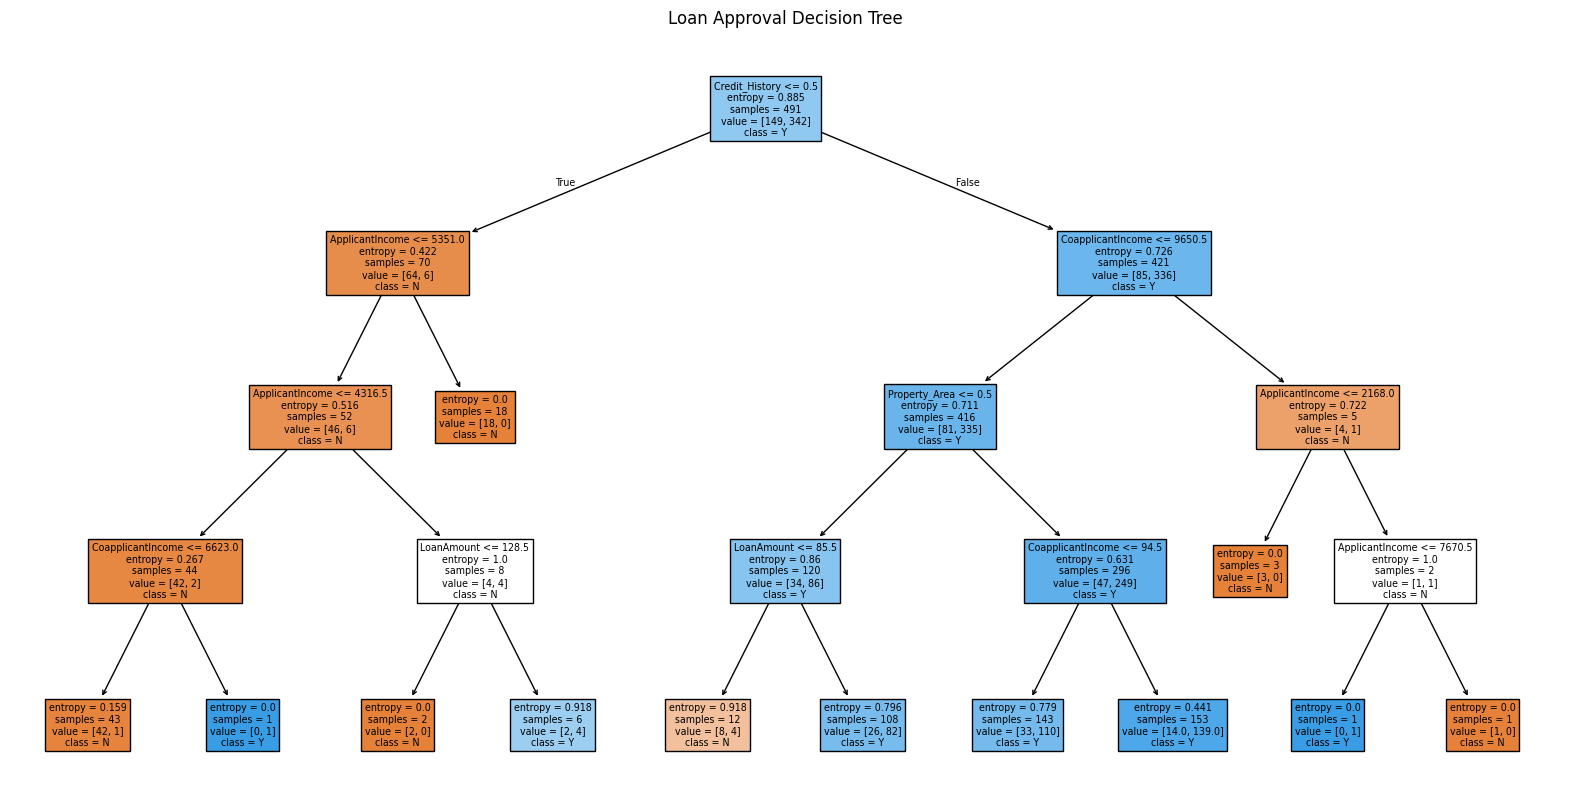

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=['N', 'Y'], filled=True)
plt.title("Loan Approval Decision Tree")
plt.show()


In [ ]:
# Drop Loan_ID for prediction
X_test = test.drop('Loan_ID', axis=1)

# Predict
test['Loan_Status'] = model.predict(X_test)

# Decode prediction
test['Loan_Status'] = le.inverse_transform(test['Loan_Status'])

# Save submission
submission = test[['Loan_ID', 'Loan_Status']]
submission.to_csv('submission.csv', index=False)
print("Submission file created.")


Submission file created.


In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Dependents']
le_dict = {}  # ✅ This dictionary stores encoders for each column

# Encode both train and test with same label encoders
for col in categorical_cols + ['Loan_Status']:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    le_dict[col] = le  # Save encoder for reuse

for col in categorical_cols:
    le = le_dict[col]
    test[col] = le.transform(test[col].astype(str))


In [ ]:
def predict_custom_loan():
    print("Enter Loan Application Details:\n")

    Gender = le_dict['Gender'].transform([input("Gender (Male/Female): ").strip().lower()])[0]
    Married = le_dict['Married'].transform([input("Married (Yes/No): ").strip().lower()])[0]
    Dependents = le_dict['Dependents'].transform([input("Dependents (0/1/2/3+): ").strip()])[0]
    Education = le_dict['Education'].transform([input("Education (Graduate/Not Graduate): ").strip().lower()])[0]
    Self_Employed = le_dict['Self_Employed'].transform([input("Self Employed (Yes/No): ").strip().lower()])[0]
    ApplicantIncome = float(input("Applicant Income: "))
    CoapplicantIncome = float(input("Coapplicant Income: "))
    LoanAmount = float(input("Loan Amount: "))
    Loan_Amount_Term = float(input("Loan Amount Term (in days): "))
    Credit_History = float(input("Credit History (0 or 1): "))
    Property_Area = le_dict['Property_Area'].transform([input("Property Area (Urban/Semiurban/Rural): ").strip().lower()])[0]

    # Combine all inputs into an array
    features = np.array([[Gender, Married, Dependents, Education, Self_Employed,
                          ApplicantIncome, CoapplicantIncome, LoanAmount,
                          Loan_Amount_Term, Credit_History, Property_Area]])

    pred = clf.predict(features)[0]
    result = le_dict['Loan_Status'].inverse_transform([pred])[0]

    print("\n📊 Prediction Result:", result)


In [ ]:
from sklearn.model_selection import train_test_split

# Drop Loan_ID from training features
X = train.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = train['Loan_Status']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

/tmp/ipython-input-1981527656.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=feature_importances.index, palette="viridis")


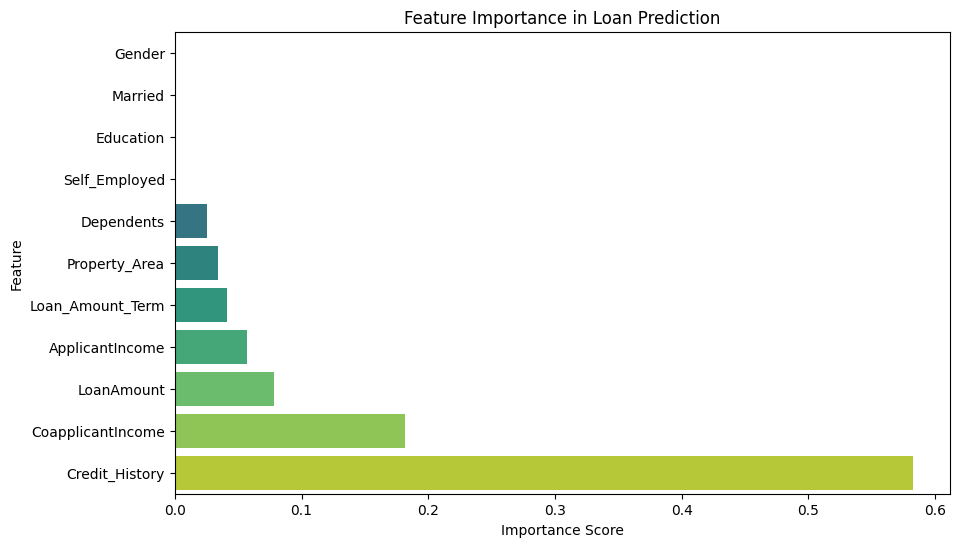

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

feature_importances = pd.Series(clf.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index, palette="viridis")
plt.title("Feature Importance in Loan Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


In [ ]:
import joblib

# Save model and encoders
joblib.dump(clf, 'loan_tree_model.pkl')
joblib.dump(le_dict, 'label_encoders.pkl')
print("Model and encoders saved.")

Model and encoders saved.


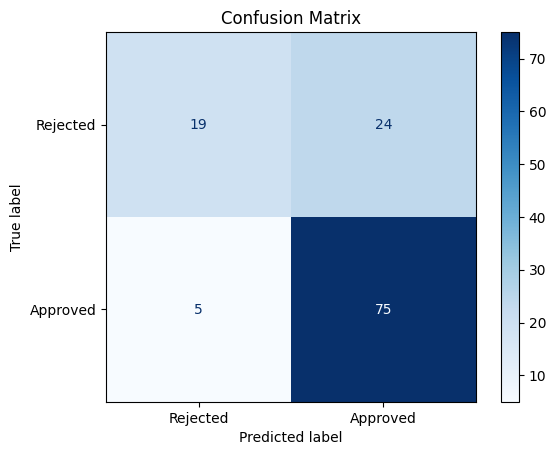

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rejected', 'Approved'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_val)

print("Random Forest Accuracy:", accuracy_score(y_val, rf_pred))


Random Forest Accuracy: 0.7560975609756098


In [ ]:
import shap

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_val)


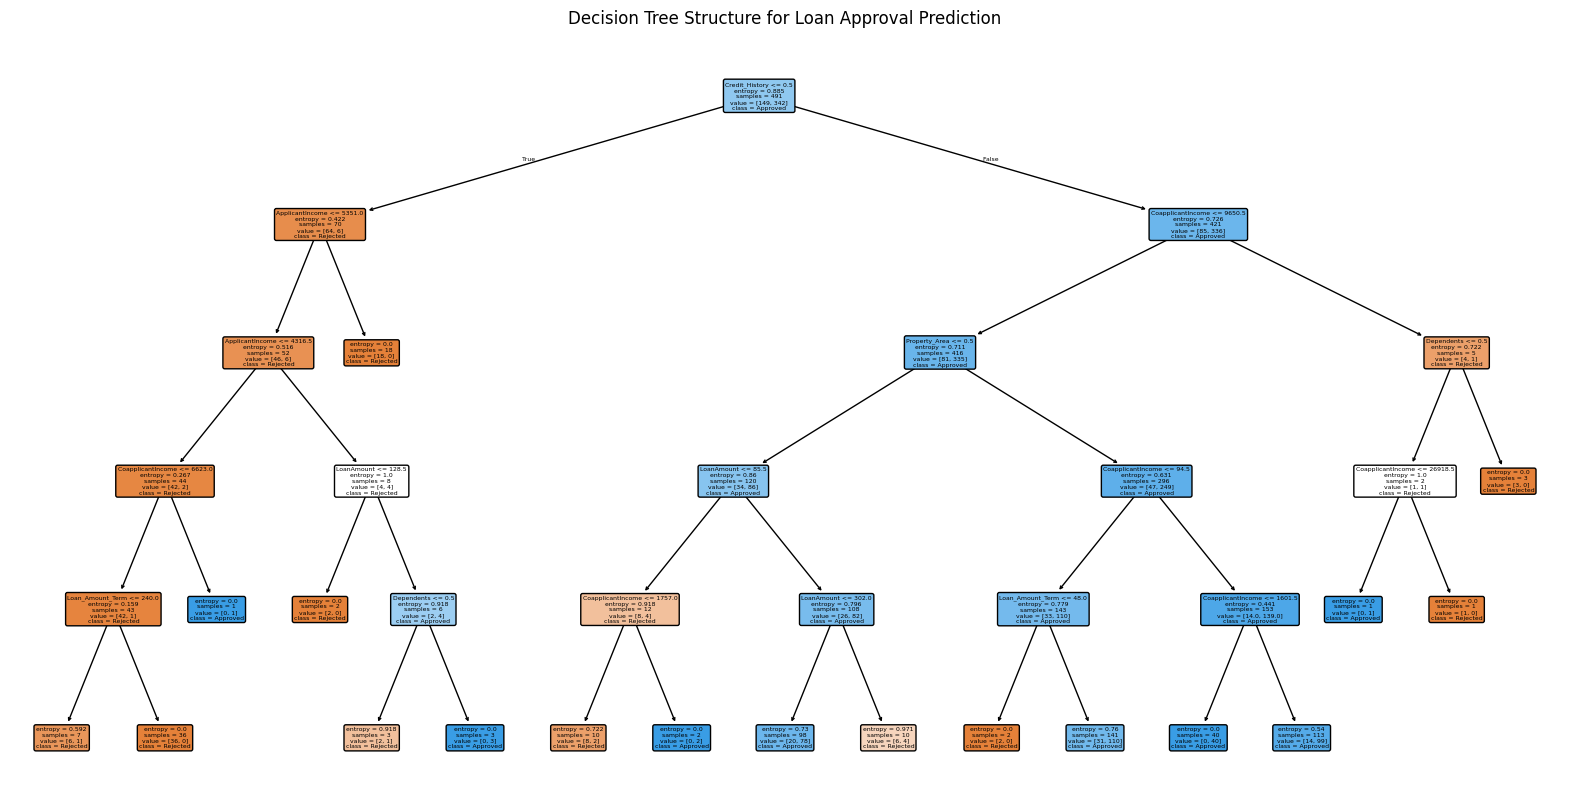

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(clf,
          feature_names=X.columns,
          class_names=["Rejected", "Approved"],
          filled=True,
          rounded=True)
plt.title("Decision Tree Structure for Loan Approval Prediction")
plt.show()


In [ ]:
clf = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)